### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [5]:
data = pd.read_csv('data/coupons.csv')

In [6]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [7]:
#get a list of variables and the not null counts
data.info()

#get the proportion of missing values for each variable
missing_summary = pd.DataFrame({
                                'missing_count': data.isnull().sum(),
                                'missing_proportion': data.isnull().mean()
                                }).sort_values(by='missing_count', ascending=False)

missing_summary

# most of the variables don't have missing values.
# Car, CoffeeHouse, Restaurant20To50, CarryAway, RestaurantLessThan20, Bar have missing values

#findings: the car variables has majority (99%)of the obs missing, 
#the other variables have a fairly small proportion of their observations missing (~0.01)
#the outcome Y has no missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

,missing_count,missing_proportion
car,12576,0.991485
CoffeeHouse,217,0.017108
Restaurant20To50,189,0.014901
CarryAway,151,0.011905
RestaurantLessThan20,130,0.010249
Bar,107,0.008436
destination,0,0.000000
passanger,0,0.000000
direction_opp,0,0.000000
direction_same,0,0.000000


3. Decide what to do about your missing data -- drop, replace, other...

In [5]:
#there are a few ways of handling missing data. 

#drop the column: if a very large proportion of the data is missing the column can be dropped. 
#For the 'Car'column ~99% obs are missing value so it can drop the column 

#impute mean/median: since the values with missing values are all categorical, the mean/median will not be applicable for them

#impute mode or create a seperate category as missing: both these options are feasible. 
#since a very small proportion of values is missing creating a missing values

cols=['car', 'CoffeeHouse', 'Restaurant20To50', 'CarryAway', 'RestaurantLessThan20', 'Bar']

for c in cols:
    if c == 'car':
        data = data.drop(columns=[c])
    else:
        data[c] = data[c].fillna('Missing')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  Bar                   12684 non-null  object
 15  CoffeeHouse           12684 non-null

4. What proportion of the total observations chose to accept the coupon?


In [8]:
outcome_prop = (data['Y'] == 1).mean()
print(f"proportion of the total observations who chose to accept the coupon {outcome_prop:2f})")

proportion of the total observations who chose to accept the coupon 0.568433)


5. Use a bar plot to visualize the `coupon` column.

Text(0, 0.5, 'Coupon Count')

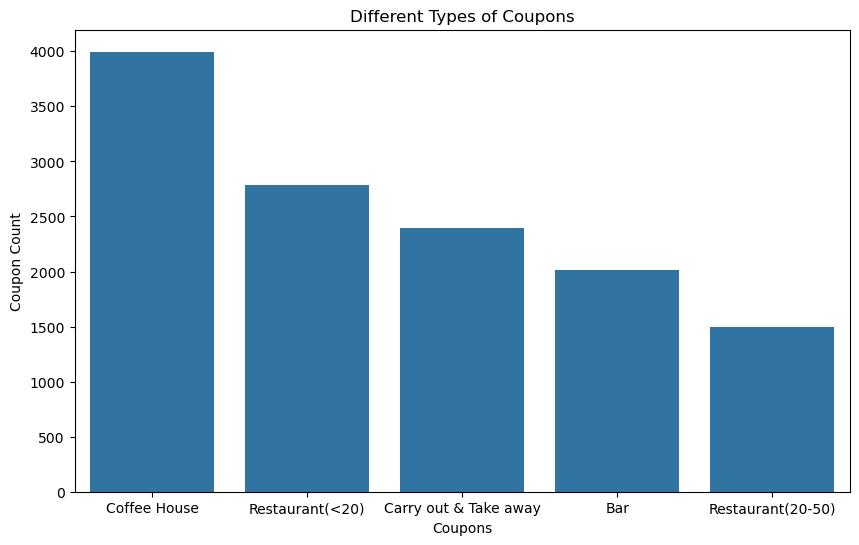

In [12]:
#get the counts of different types of coupons

#print(data['coupon'].value_counts(normalize=True))

countplt=data['coupon'].value_counts().reset_index()
#print(countplt)

#generate a barplot 
plt.figure(figsize=(10, 6))
sns.barplot(x='coupon', y='count', data=countplt)
plt.title("Different Types of Coupons")
plt.xlabel("Coupons")
plt.ylabel("Coupon Count")

#finding: Coffee House is the most common type of coupon, followed by Restaurant(<20), Carry out & Take away Coupons, Bar, and Restaurant(20-50)

6. Use a histogram to visualize the temperature column.

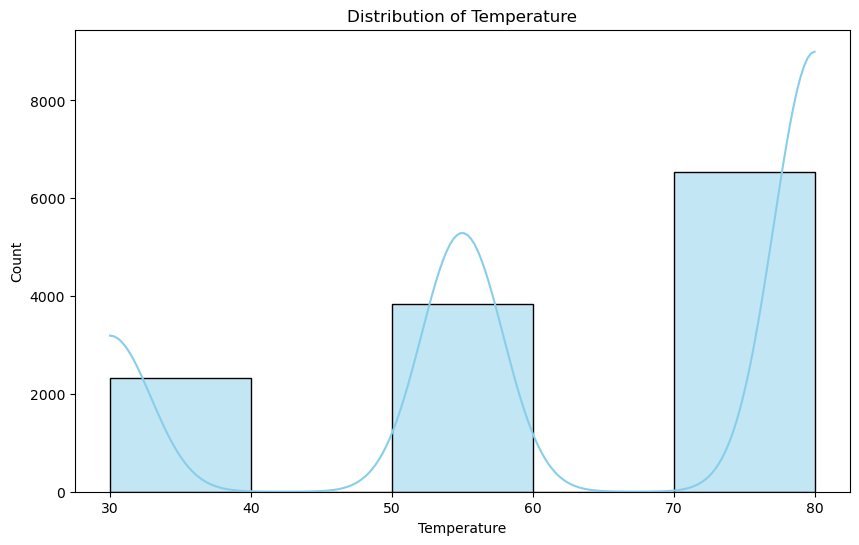

In [13]:
#plot histogram of temperature values
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='temperature', bins=5, kde=True, color='skyblue')
plt.title('Distribution of Temperature')
plt.xlabel('Temperature')
plt.ylabel('Count')
plt.show()

#the temperature is between 70-80 for most of the observations, followed by 50-60, and 30-40

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [14]:
data_bar=data[data['coupon']=='Bar']
data_bar.shape

(2017, 26)

2. What proportion of bar coupons were accepted?


In [15]:
prop_coupons_acc=(data_bar['Y']==1).mean()
print(f"Proportion of Bar Coupons {prop_coupons_acc:.2f}")

Proportion of Bar Coupons 0.41


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [16]:
#understand what values the variables can take
for col in data_bar.columns:
    print(f"\nColumn: {col}")
    print(data_bar[col].unique())


Column: destination
['No Urgent Place' 'Home' 'Work']

Column: passanger
['Kid(s)' 'Alone' 'Friend(s)' 'Partner']

Column: weather
['Sunny' 'Rainy' 'Snowy']

Column: temperature
[80 55 30]

Column: time
['10AM' '6PM' '7AM' '10PM' '2PM']

Column: coupon
['Bar']

Column: expiration
['1d' '2h']

Column: gender
['Female' 'Male']

Column: age
['21' '46' '26' '31' '41' '50plus' '36' 'below21']

Column: maritalStatus
['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']

Column: has_children
[1 0]

Column: education
['Some college - no degree' 'Bachelors degree' 'Associates degree'
 'High School Graduate' 'Graduate degree (Masters or Doctorate)'
 'Some High School']

Column: occupation
['Unemployed' 'Architecture & Engineering' 'Student'
 'Education&Training&Library' 'Healthcare Support'
 'Healthcare Practitioners & Technical' 'Sales & Related' 'Management'
 'Arts Design Entertainment Sports & Media' 'Computer & Mathematical'
 'Life Physical Social Science' 'Personal Care & S

In [17]:
#create a variable 'bar_grouped'

def group_bar(x):
    if x in ['never', 'less1', '1~3']:
        return '<3'
    elif x in ['4~8', 'gt8']:
        return '>=3'
    else:
        return 'Missing'

data_bar = data_bar.copy()  # create a safe copy
data_bar['Bar_grouped'] = data_bar['Bar'].apply(group_bar)

#run crosstabs to compare the acceptance rate
acceptance_rate=pd.crosstab(data_bar['Bar_grouped'] , data_bar['Y']==1,normalize='index')
print(acceptance_rate)

#finding: the coupon acceptance rate is much higher among people going to bars >3 times a week as compared to those going less than 3 times (76% vs 37%)

Y               False     True 
Bar_grouped                    
<3           0.629382  0.370618
>=3          0.231156  0.768844
Missing      0.619048  0.380952


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [18]:
#create the 'Bar_25gt_grouped' variable

data_bar = data_bar.copy() 
data_bar['Bar_25gt_grouped'] = np.where((data_bar['Bar'].isin(['1~3','4~8', 'gt8']) & data_bar['age'].isin(['26','31','36','41','46','50plus'])), 1, 0)
#run crosstabs
acceptance_rate=pd.crosstab(data_bar['Bar_25gt_grouped'] , data_bar['Y']==1,normalize='index')
print(acceptance_rate)

#finding: drivers going to bars who are greater than 25 years are more likely to accept the coupons as compared to others

Y                    False     True 
Bar_25gt_grouped                    
0                 0.664997  0.335003
1                 0.304762  0.695238


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [19]:
#create a 'Bar_Kid_Occ' variable

data_bar = data_bar.copy() 
data_bar['Bar_Kid_Occ']=np.where(~data_bar['occupation'].isin(['Farming Fishing & Forestry']) & 
                                 ~data_bar['passanger'].isin(['Kid(s)']) & 
                                 data_bar['Bar'].isin(['1~3', '4~8', 'gt8']),
                                 1, 0)


acceptance_rate=pd.crosstab(data_bar['Bar_Kid_Occ'] , data_bar['Y']==1,normalize='index')
print(acceptance_rate)

#finding: drivers who go to bars more than once a month and 
#had passengers that were not a kid and had occupations other than farming, fishing, or forestry are more likely to accept the coupon as compared to others (71% vs 29%)

Y               False     True 
Bar_Kid_Occ                    
0            0.703956  0.296044
1            0.286751  0.713249


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [20]:
#create an indicator variable for each of the 3 conditions
#create a indicator variable 'ind_any_cond_match'=1 if any of the 3 conditions is met and compare the acceptance rate using crosstab

data_bar = data_bar.copy() 
data_bar['ind_bar_notkid_notwid']=np.where(data_bar['Bar'].isin(['1~3','4~8','gt8']) & ~data_bar['passanger'].isin(['Kid(s)']) & ~data_bar['maritalStatus'].isin(['Widowed']),1,0)
data_bar['ind_bar_ageund30']=np.where(data_bar['Bar'].isin(['1~3','4~8','gt8']) & data_bar['age'].isin(['below21','21','26']),1,0)
data_bar['ind_cheaprest_50k']=np.where(~data_bar['RestaurantLessThan20'].isin(['4~8','gt8']) & data_bar['income'].isin(['Less than $12500','$12500 - $24999','$25000 - $37499','$37500 - $49999']),1,0)

data_bar['ind_any_cond_match']=np.where((data_bar['ind_bar_notkid_notwid']==1) | (data_bar['ind_bar_ageund30']==1) | (data_bar['ind_cheaprest_50k']==1), 1,0)


acceptance_rate=pd.crosstab(data_bar['ind_any_cond_match'] , data_bar['Y']==1,normalize='index')
print(acceptance_rate)

#finding: the acceptance rate is higher among drivers who meet any of the above 3 criterias as compared to others (52% vs 27%)

Y                      False     True 
ind_any_cond_match                    
0                   0.721436  0.278564
1                   0.479964  0.520036


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [136]:
#based on these observations Bar coupons should be targeted at frequent bar-goers (3+ visits/month) 
#who are over 25 and traveling without children.


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [21]:
print(data['coupon'].value_counts())
data.columns

coupon
Coffee House             3996
Restaurant(<20)          2786
Carry out & Take away    2393
Bar                      2017
Restaurant(20-50)        1492
Name: count, dtype: int64


Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse',
       'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50',
       'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min',
       'direction_same', 'direction_opp', 'Y'],
      dtype='object')

In [22]:
#exploring patterns/characteristics that carry out & take away coupons

In [23]:
#susbet the data to keep only coupons for carry out and take away 
data_cryout_takeaway=data[data['coupon']=='Carry out & Take away']
data_cryout_takeaway.shape

(2393, 26)

In [28]:
#coupon accepatance rate for carry out and take away coupons
print((data_cryout_takeaway['Y']==1).sum()/data_cryout_takeaway['Y'].count())

#finding: the overall acceptance rate for carry out and take away coupons is 73%

0.7354784788967823


In [30]:
#check which variables are correlated to the outcome
data_cryout_takeaway.dtypes

for col in data_cryout_takeaway.columns:
    print(f"\nColumn: {col}")
    print(data_cryout_takeaway[col].unique())

 #finding: looking at the possible values the variable can take all the variables seem categorical variables


Column: destination
['No Urgent Place' 'Work' 'Home']

Column: passanger
['Friend(s)' 'Kid(s)' 'Alone' 'Partner']

Column: weather
['Sunny' 'Rainy' 'Snowy']

Column: temperature
[80 55 30]

Column: time
['10AM' '2PM' '7AM' '10PM' '6PM']

Column: coupon
['Carry out & Take away']

Column: expiration
['2h' '1d']

Column: gender
['Female' 'Male']

Column: age
['21' '46' '26' '31' '41' '50plus' '36' 'below21']

Column: maritalStatus
['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']

Column: has_children
[1 0]

Column: education
['Some college - no degree' 'Bachelors degree' 'Associates degree'
 'High School Graduate' 'Graduate degree (Masters or Doctorate)'
 'Some High School']

Column: occupation
['Unemployed' 'Architecture & Engineering' 'Student'
 'Education&Training&Library' 'Healthcare Support'
 'Healthcare Practitioners & Technical' 'Sales & Related' 'Management'
 'Arts Design Entertainment Sports & Media' 'Computer & Mathematical'
 'Life Physical Social Science' 

In [31]:
#quick check on missingness
missing_summary_takeout = pd.DataFrame({
                                'missing_count': data_cryout_takeaway.isnull().sum(),
                                'missing_proportion': data_cryout_takeaway.isnull().mean()
                                }).sort_values(by='missing_count', ascending=False)

print(missing_summary_takeout)
#since we have already removed 'car' columnn and added 'missing' for missing obs we don't see any missing values 
data_cryout_takeaway.columns
data_cryout_takeaway.shape

                      missing_count  missing_proportion
car                            2374            0.992060
Restaurant20To50                 33            0.013790
CoffeeHouse                      32            0.013372
CarryAway                        22            0.009193
RestaurantLessThan20             18            0.007522
Bar                              16            0.006686
destination                       0            0.000000
passanger                         0            0.000000
direction_opp                     0            0.000000
direction_same                    0            0.000000
toCoupon_GEQ25min                 0            0.000000
toCoupon_GEQ15min                 0            0.000000
toCoupon_GEQ5min                  0            0.000000
income                            0            0.000000
occupation                        0            0.000000
education                         0            0.000000
has_children                      0            0

(2393, 26)

In [33]:
#compare all the variables to understand how closely they are related to the outcome
cat_cols = data_cryout_takeaway.columns

for col in cat_cols:
    if col != 'Y':
        print(f"\n{col}")
        print(pd.crosstab(data_cryout_takeaway[col], data_cryout_takeaway['Y'], normalize='index'))

#findings: 
#destination=work has low acceptance rate as compared to home/no urgent place
#having a kid passanger leads to a low acceptance rate
#higher acceptance rate in sunny weather as compared to snow/rain
#no major differences in acceptance rate by temperature
#less likely to accept coupons in the morning around 7am
#more likely to accept coupons that end next day as compared to in 2hrs
#no major differences in acceptance rate by sex  and age (50 plus slightly more likely to accept coupons)  
#widowed people are more likely to accept coupons
#drivers with highschool or associates degree are more likely to accept coupons
#no major differences by occupation and income
#slightly lower acceptance rate for more frequent bar goers and CoffeeHouse goers
#no major differences by carryout (slightly higher acceptance rate among those with missing observations)
#slighlty higher acceptance rate among those who don't go to cheap restaurants (RestaurantLessThan20)
#slighly lower acceptance rate among drivers going frequently to expensive restaurants (Restaurant20To50)
#slightly lower acceptance rate in the same direction and slightly higher acceptance rate in the opposite direction(looks counterintuitive)


destination
Y                       0         1
destination                        
Home             0.211332  0.788668
No Urgent Place  0.237219  0.762781
Work             0.345144  0.654856

passanger
Y                 0         1
passanger                    
Alone      0.272598  0.727402
Friend(s)  0.242219  0.757781
Kid(s)     0.296053  0.703947
Partner    0.268041  0.731959

weather
Y               0         1
weather                    
Rainy    0.388715  0.611285
Snowy    0.293160  0.706840
Sunny    0.237125  0.762875

temperature
Y                   0         1
temperature                    
30           0.243675  0.756325
55           0.281250  0.718750
80           0.270169  0.729831

time
Y            0         1
time                    
10AM  0.297872  0.702128
10PM  0.240781  0.759219
2PM   0.133028  0.866972
6PM   0.174713  0.825287
7AM   0.345144  0.654856

coupon
Y                             0         1
coupon                                   
Carry out & Take away

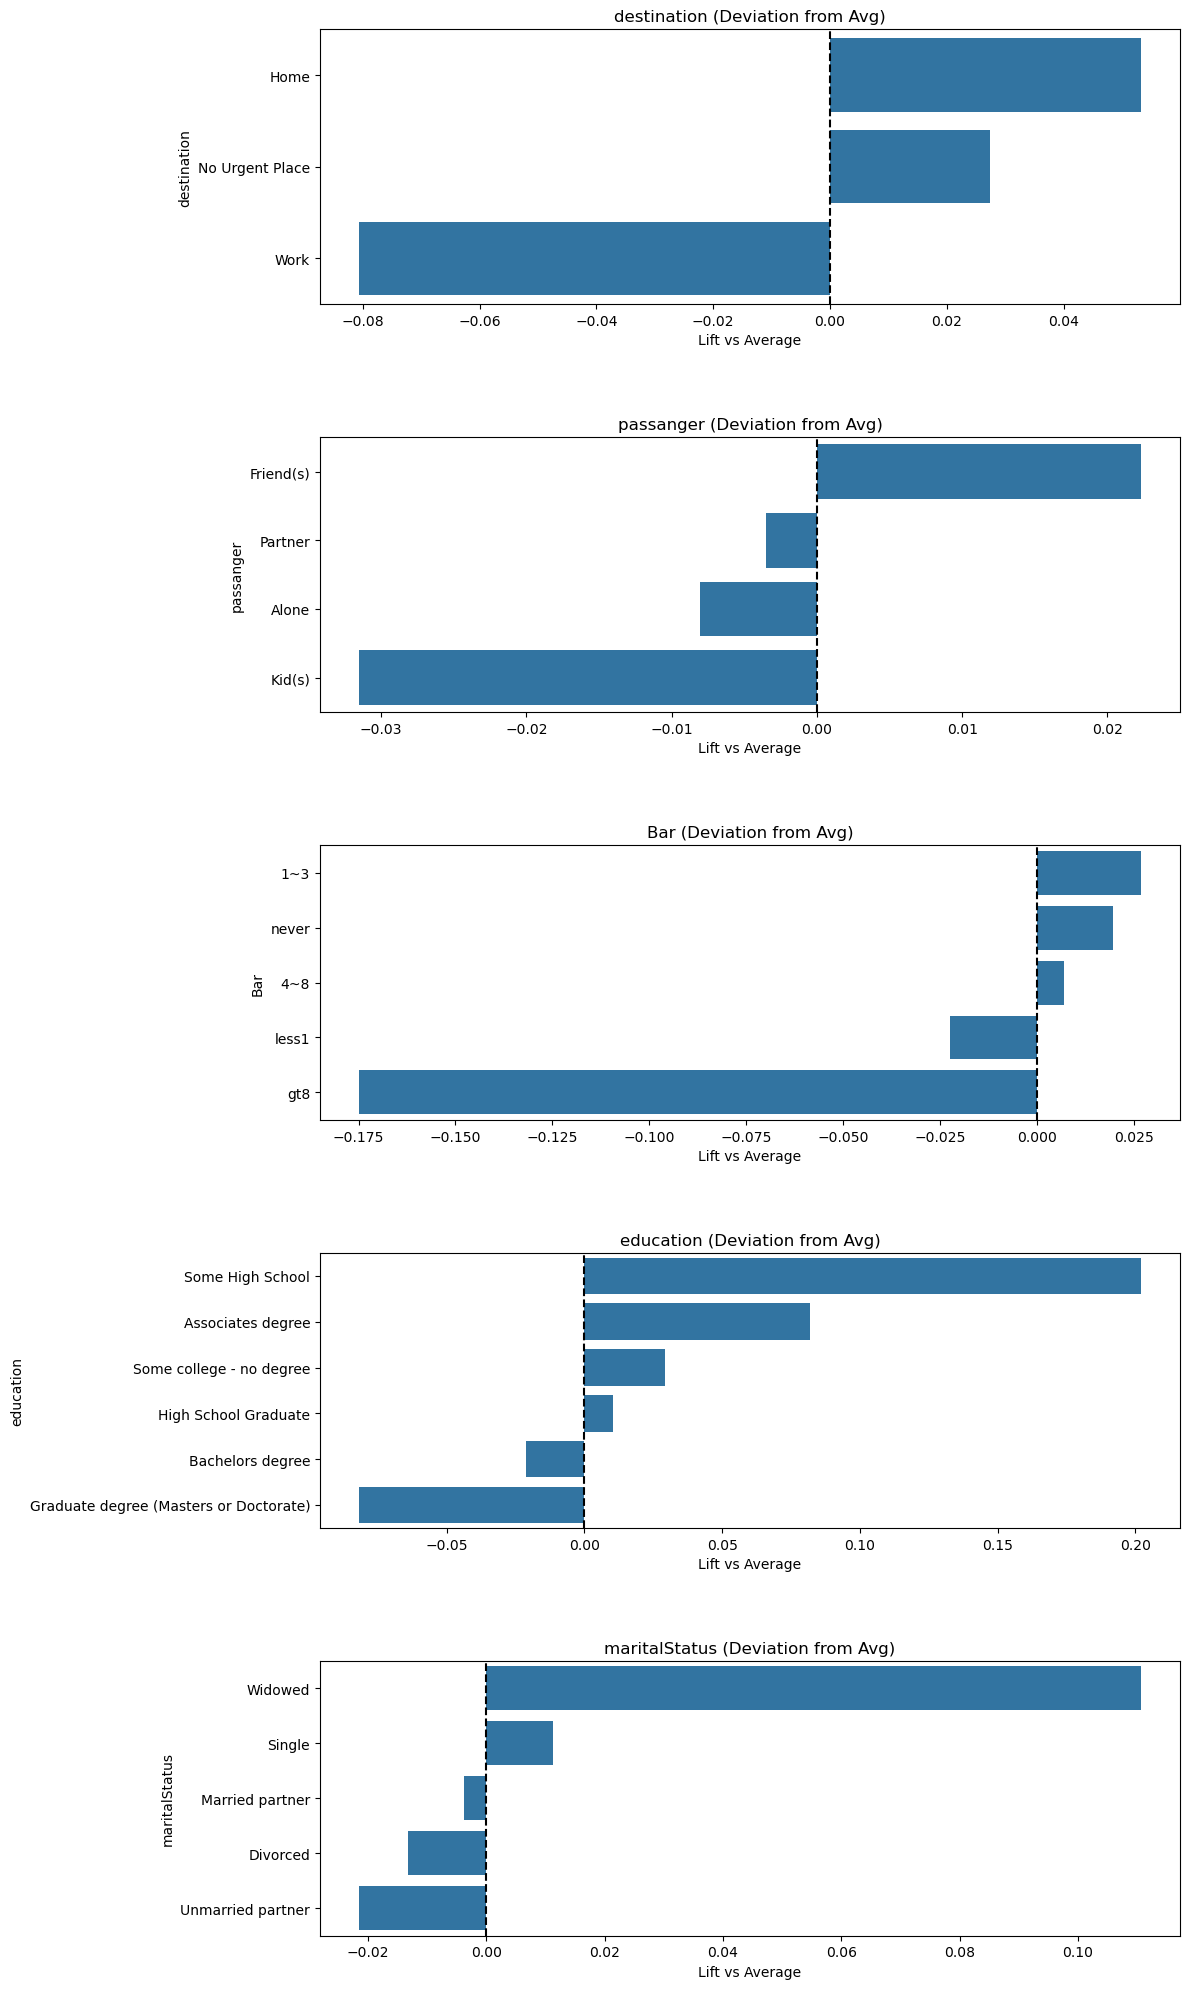

In [34]:
##generate plots to visualize the most common categories with large variations in the acceptance rate
cols_plt=['destination','passanger','Bar', 'education',  'maritalStatus']

overall = data_cryout_takeaway['Y'].mean()
#print (overall)
fig, axes = plt.subplots(len(cols_plt), 1, figsize=(12, 20))

for i, col in enumerate(cols_plt):
    rate = data_cryout_takeaway.groupby(col)['Y'].mean().reset_index()
    rate['diff'] = rate['Y'] - overall
    rate = rate.sort_values(by='diff', ascending=False)
    
    sns.barplot(data=rate, x='diff', y=col, ax=axes[i])
    
    axes[i].axvline(0, color='black', linestyle='--')
    axes[i].set_title(f"{col} (Deviation from Avg)")
    axes[i].set_xlabel("Lift vs Average")

plt.tight_layout(h_pad=5)

#findings: These plots compare the acceptance rate 'Carry Out and Take Away' for each subgroup with the average acceptance rate (73.5%). 
#We see similar trends as the above crosstabulation 
# destination:  the acceptance rate for is higher for drivers goinng home or no urgent place and less among those going to work
# passengar: the acceptance rate is higher is there are with friends and lower among those with a partner/kids or alone
# Bar goers: the acceptance rate is much lower among those going to bars frequently (gt 8 times)
# education level: the acceptance rate is highest among those with some high school degree/associates degree and lowest among those with a graduate degree
# marital status: the acceptance rate is highest among widowed and single people and lowest amonng those with a unmarried partner
#Note: all comparisons are relative to the avg acceptance rate

#Overall, it seems that the drivers doing non urgent tasks, not having kids in the car, 
#having a high school/associates degree,and widowed/single are more likely to accept the carry out and take away coupons